In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json

plt.style.use("~/PhD/subdom_asym/code_subdom_asym/MATPLOTLIB_RCPARAMS.sty")

In [2]:
with open("QNM_results.json") as input_file:
    data = json.load(input_file)

In [3]:
def chi_p(chi1, chi2, q):

    L_hat = np.array([0, 0, 1])  
    
    chi1_perp = np.linalg.norm(np.cross(chi1, L_hat))
    chi2_perp = np.linalg.norm(np.cross(chi2, L_hat))
    
    factor = (3 + 4 * q) / (4 + 3 * q)
    chi_p = max(chi1_perp, factor * chi2_perp)
    
    return chi_p 


def chi_eff(chi1, chi2, q):
    return (q*chi1[2] + chi2[2]) / (1+q)


In [4]:
modes = [(2, 2), (2, 1), (3, 3), (3, 2), (3, 1)]
ratios = {}
diffs = {}
vs = {}
phis = {}
chi_ps = {}
chi_effs = {}
qs = {}
chi1s = {}
chi2s = {}

for mode in modes:
    l, m = mode
    for id_ in data.keys():  
        key_pos = f"({l},{m},0,1)"
        key_neg = f"({l},{-m},0,-1)"
        
        ampl_pos = np.linalg.norm(data[id_][key_pos]['A'])
        ampl_neg = np.linalg.norm(data[id_][key_neg]['A']) 
        ratio = ampl_pos / ampl_neg
        diff = np.abs(data[id_][key_pos]['A'][0] + 1j*data[id_][key_pos]['A'][1] 
                      - (-1)**l * data[id_][key_neg]['A'][0] + 1j*data[id_][key_neg]['A'][1])
        
        ratios[(id_, l, m)] = ratio
        diffs[(id_, l, m)] = diff
        vs[id_] = data[id_]["kick rapidity"]
        phis[id_] = data[id_]["kick theta"]
        chi_ps[id_] = chi_p(data[id_]["chi1"], data[id_]["chi2"], data[id_]["q"])
        chi_effs[id_] = chi_eff(data[id_]["chi1"], data[id_]["chi2"], data[id_]["q"])
        chi1s[id_] = data[id_]["chi1"]
        chi2s[id_] = data[id_]["chi2"]
        qs[id_] = data[id_]["q"]

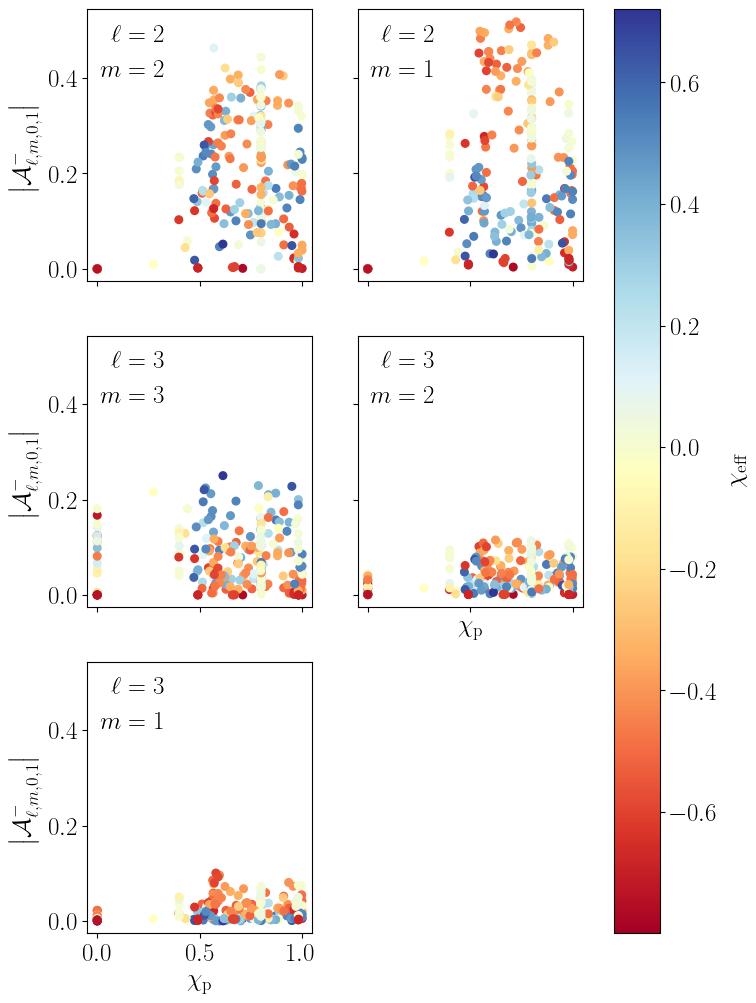

In [ ]:
fig, axs = plt.subplots(3, 2, figsize=(8, 12), sharex=True, sharey=True)
axs = axs.flatten()

for i, (ell, m) in enumerate(modes):
    x = [] 
    y = []  
    c = [] 
    for id_ in data.keys():
        x.append(chi_ps[id_])
        y.append(diffs[(id_, ell, m)])
        c.append(chi_effs[id_])

    sc = axs[i].scatter(x, y, c=c, cmap='RdYlBu', s=30)
    axs[i].text(0.2, 0.85, r"$\begin{aligned}\ell &= %s \\ m &= %s\end{aligned}$" % (ell,m),
            ha='center', va='center',
            transform=axs[i].transAxes,
            color='black')


axs[0].set_ylabel(r'$\big|\mathcal{A}^-_{\ell, m, 0, 1}\big|$')
axs[2].set_ylabel(r'$\big|\mathcal{A}^-_{\ell, m, 0, 1}\big|$')
axs[4].set_ylabel(r'$\big|\mathcal{A}^-_{\ell, m, 0, 1}\big|$')
axs[3].set_xlabel(r"$\chi_\text{p}$")
axs[4].set_xlabel(r"$\chi_\text{p}$")

if len(modes) < len(axs):
    axs[-1].axis("off")

cbar = fig.colorbar(sc, ax=axs.ravel().tolist())
cbar.set_label(r"$\chi_{\text{eff}}$")

# plt.savefig('asym_rd_ampls.pdf')
plt.show()